---
title: "The titles of the Diario Oficial, 1970--2026"
subtitle: "A first exploration of the note archive"
date: 2026-07-17
author:
  - name: INGEOTEC
abstract: >
  We examine the titles of the 983,337 notes published in Mexico's Diario
  Oficial de la Federación between January 1970 and July 2026, obtained from
  the gazette's own open-data service. The analysis of yearly volume, of the
  first word of each title, of title length and of vocabulary reveals three
  major transformations: the expansion of the gazette from 1999 onward, when
  the systematic cataloguing of procurement announcements and notices doubled
  the number of notes; the displacement of the classic legal instruments —
  resoluciones and decretos — by the administrative aviso as the dominant
  documentary form; and the correlative impoverishment of the title as a
  descriptor, whose median length fell from twenty-five words to six.
---

In [1]:
#| label: setup
#| include: false
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

# The aggregated CSVs live next to the site's sources; when this notebook runs
# elsewhere (e.g. Google Colab) they are fetched from the repository instead.
DATA_DIR = Path("../data")
DATA_URL = "https://raw.githubusercontent.com/INGEOTEC/LegalIA/master/website/data"


def load(name):
    local = DATA_DIR / name
    return pd.read_csv(local if local.exists() else f"{DATA_URL}/{name}")


# Validated categorical palette (light mode), in fixed assignment order.
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
LIGHT_BLUE = "#9ec5f4"  # step 200 of the blue sequential ramp
INK, MUTED, GRID, AXIS = "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": INK,
        "font.size": 10,
        "axes.axisbelow": True,
    }
)


def clean_axis(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.tick_params(length=0)
    ax.set_xlabel("")


def thousands(x, _):
    return f"{int(x):,}"


notes = load("notes_per_year.csv")
days = load("days_with_notes.csv")
length = load("title_length.csv")
first_words = load("first_words.csv")
headings = load("headings.csv")
terms = load("terms_by_decade.csv")

per_year = notes.groupby("year").notes.sum()

## The title as an object of study

Every note in the *Diario Oficial de la Federación* is born with a title.
Before there is any digitized full text, OCR or structural markup, the title
is the only descriptor that accompanies each document across the entire
archive: it says what kind of instrument is being published, who issues it and
what it is about. That is why this first exploration deals exclusively with
that minimal piece of metadata. If titles allow us to reconstruct, even in
broad strokes, the documentary history of the gazette, then they are a solid
foundation for the classification and retrieval tasks that will follow.

The material comes from the DOF's open-data service, from which the daily
summary of notes was downloaded for every day between January 1, 1970 and July
17, 2026. The result is 983,337 notes spread over 14,637 publication days: the
gazette appears, on average, 259 days a year — practically every business day.
A methodological caveat is in order: the metadata for the decades before
digitization was captured retrospectively by the gazette itself, so the unit
*note* reflects cataloguing criteria that are not constant over time. Part of
what follows documents precisely those changes of criteria.

## How many notes the State publishes

The yearly series of the number of notes divides the recent history of the
gazette in two ([@fig-volume]). Between 1970 and 1998 the DOF published around
seven thousand notes a year, with swings that track the six-year presidential
cycles but no sustained trend. In 1999 the volume jumps from 12,921 to 28,238
notes — more than double — and never comes back: the 2010s settle above thirty
thousand notes a year, peaking at 36,041 in 2014. The jump does not reflect a
legislative explosion but a change in cataloguing: as will become clear below,
this is the moment when procurement announcements and judicial and general
notices — which had always existed in the gazette's pages — begin to be
recorded as individual notes in the electronic system.

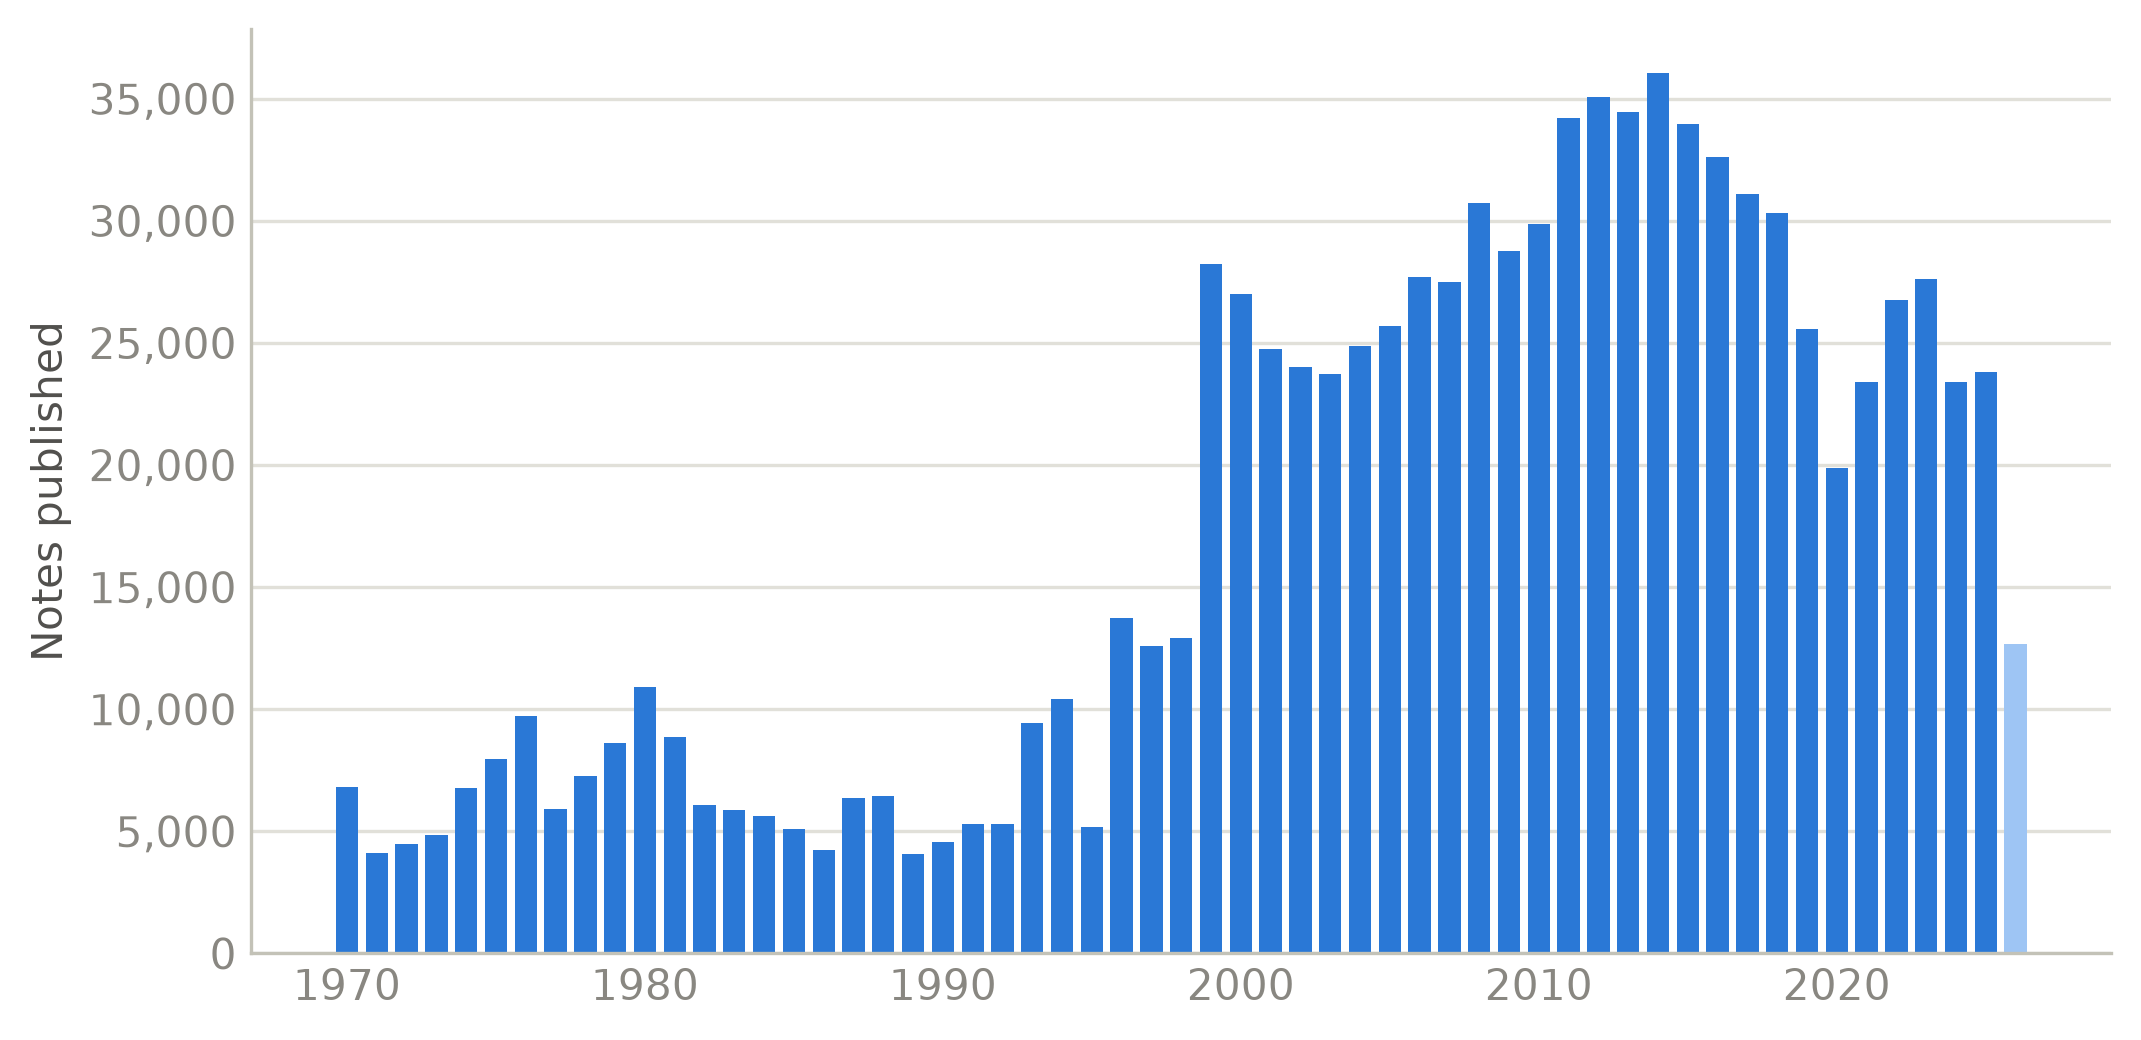

In [2]:
#| label: fig-volume
#| fig-cap: "Notes published in the DOF per year, 1970–2026. The 2026 bar (lighter) covers only through July 17."
fig, ax = plt.subplots(figsize=(8, 4))
colors = [LIGHT_BLUE if y == 2026 else BLUE for y in per_year.index]
ax.bar(per_year.index, per_year.values, color=colors, width=0.75)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylabel("Notes published")
clean_axis(ax)
plt.show()

Two recent episodes deserve mention. The decline of 2019--2020 — from thirty
thousand to 19,889 notes — coincides with the change of federal government,
its austerity policy and, in 2020, the suspension of activities during the
COVID-19 pandemic; the subsequent recovery is only partial. The evening
edition, which the archive registers only from the 2000s onward, remains
marginal: 3,177 notes over the whole period, three in every thousand, although
its use has become more frequent in the current decade.

## The first word: a de facto documentary typology

DOF titles follow a stable convention: they open with the name of the
instrument being published — "DECRETO por el que…" (*decree whereby…*),
"ACUERDO que establece…" (*agreement establishing…*), "AVISO de…" (*notice
of…*) — or, in the announcement sections, with the name of the convening
body. The first word of the title thus works as a de facto documentary
typology, and its evolution summarizes half a century of administrative
history ([@fig-instruments]).

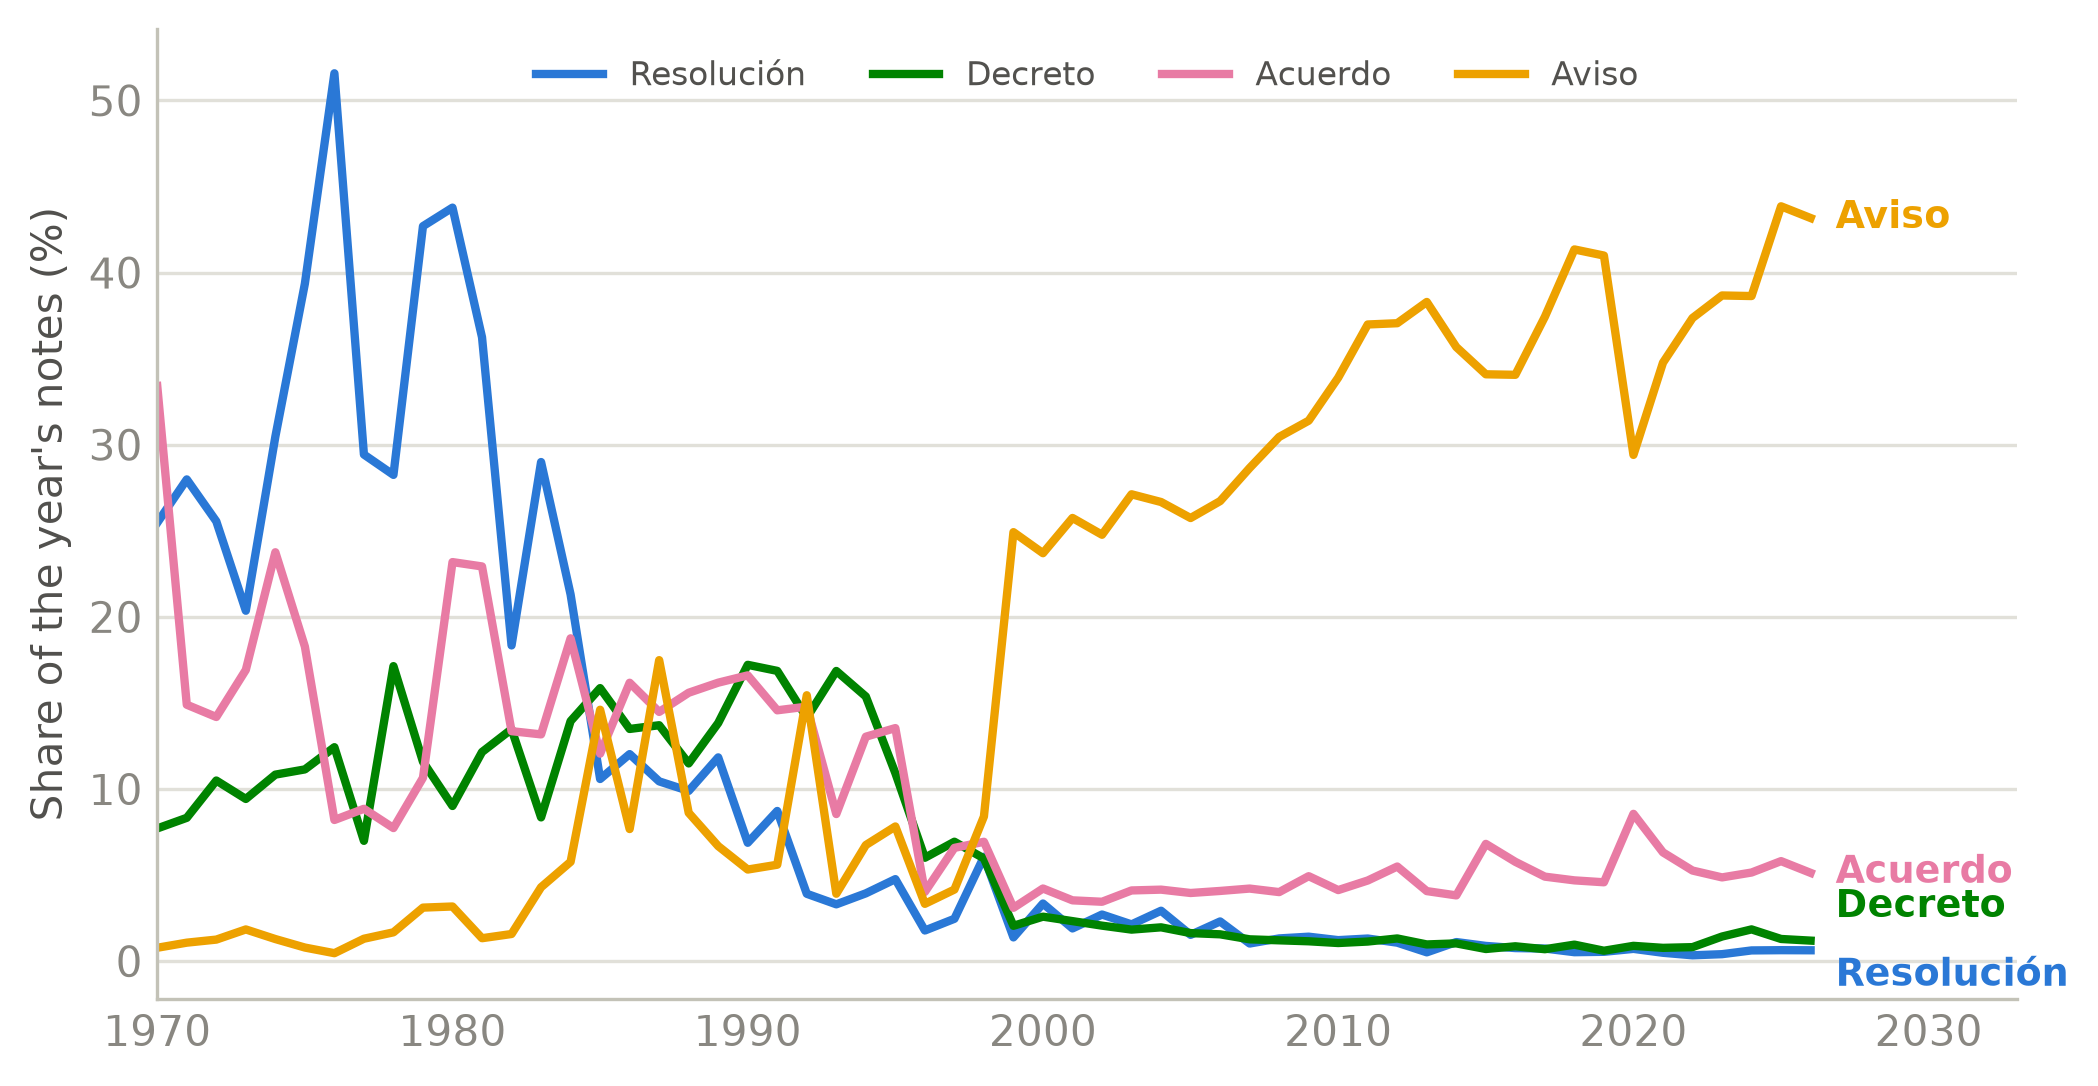

In [3]:
#| label: fig-instruments
#| fig-cap: "Yearly share of the four most telling first words in DOF titles: resolución (resolution), decreto (decree), acuerdo (agreement) and aviso (notice). Each series is labeled directly on the curve."
selection = {
    "RESOLUCION": ("Resolución", BLUE),
    "DECRETO": ("Decreto", GREEN),
    "ACUERDO": ("Acuerdo", MAGENTA),
    "AVISO": ("Aviso", YELLOW),
}

piv = first_words.pivot_table(index="year", columns="word", values="notes", aggfunc="sum").fillna(0)
share = piv.div(piv.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
# Vertical offset (in points) so labels of series that end at almost the same
# level do not overlap.
dodge = {"DECRETO": 8, "RESOLUCION": -6}
for word, (label, color) in selection.items():
    series = share[word]
    ax.plot(series.index, series.values, color=color, linewidth=2, label=label)
    ax.annotate(
        label,
        xy=(series.index[-1], series.values[-1]),
        xytext=(6, dodge.get(word, 0)),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="bold",
        va="center",
    )
ax.set_ylabel("Share of the year's notes (%)")
ax.set_xlim(1970, 2033)
ax.legend(frameon=False, fontsize=8, loc="upper center", ncols=4)
clean_axis(ax)
plt.show()

In 1975, four out of every ten titles began with the word *Resolución*. These
were not just any administrative resolutions: they were, overwhelmingly,
agrarian resolutions — grants and extensions of *ejidos* (communal
landholdings), deprivations of agrarian rights, creations of new population
centers — the daily paperwork of Mexico's land reform. As land distribution
wound down and the 1992 reform of Article 27 of the Constitution closed the
era, that documentary mass vanishes: by 2025 resolutions barely reach one
percent of the notes. The *Decreto*, the classic form of presidential action,
follows a similar though less abrupt trajectory, from eleven percent to little
more than one.

The opposite movement belongs to the *Aviso*. Practically absent in the 1970s
— under one percent of the titles — it is today the first word of 43.8 percent
of the notes, and of 27.2 percent over the whole period. If avisos are added
to acuerdos, resoluciones, decretos, convenios, circulares and declaratorias,
almost half of the titles in the archive open with one of these seven
instruments; the rest correspond mostly to titles that open with the name of
an institution — *Instituto*, *Secretaría*, *Comisión*, *Pemex* — the
signature of procurement and job-opening announcements.

## Titles that shrink

The change in documentary composition left a sharp imprint on the very shape
of the titles ([@fig-length]). During the 1970s and 1980s the median title ran
to about twenty-five words: the typical agrarian resolution named the village,
the municipality and the state involved, in addition to the nature of the
proceeding. From 1999 onward the median collapses and settles at six words.
The explanation is not that legal instruments are named more economically
today, but once again composition: the announcements and notices that flood
the gazette from then on carry minimal titles — the agency's name followed by
a docket number, as in "INSTITUTO MEXICANO DEL SEGURO SOCIAL - REF:501748" —
which drag the distribution down. The mean, more sensitive to the long titles
that survive among normative instruments, declines less severely.

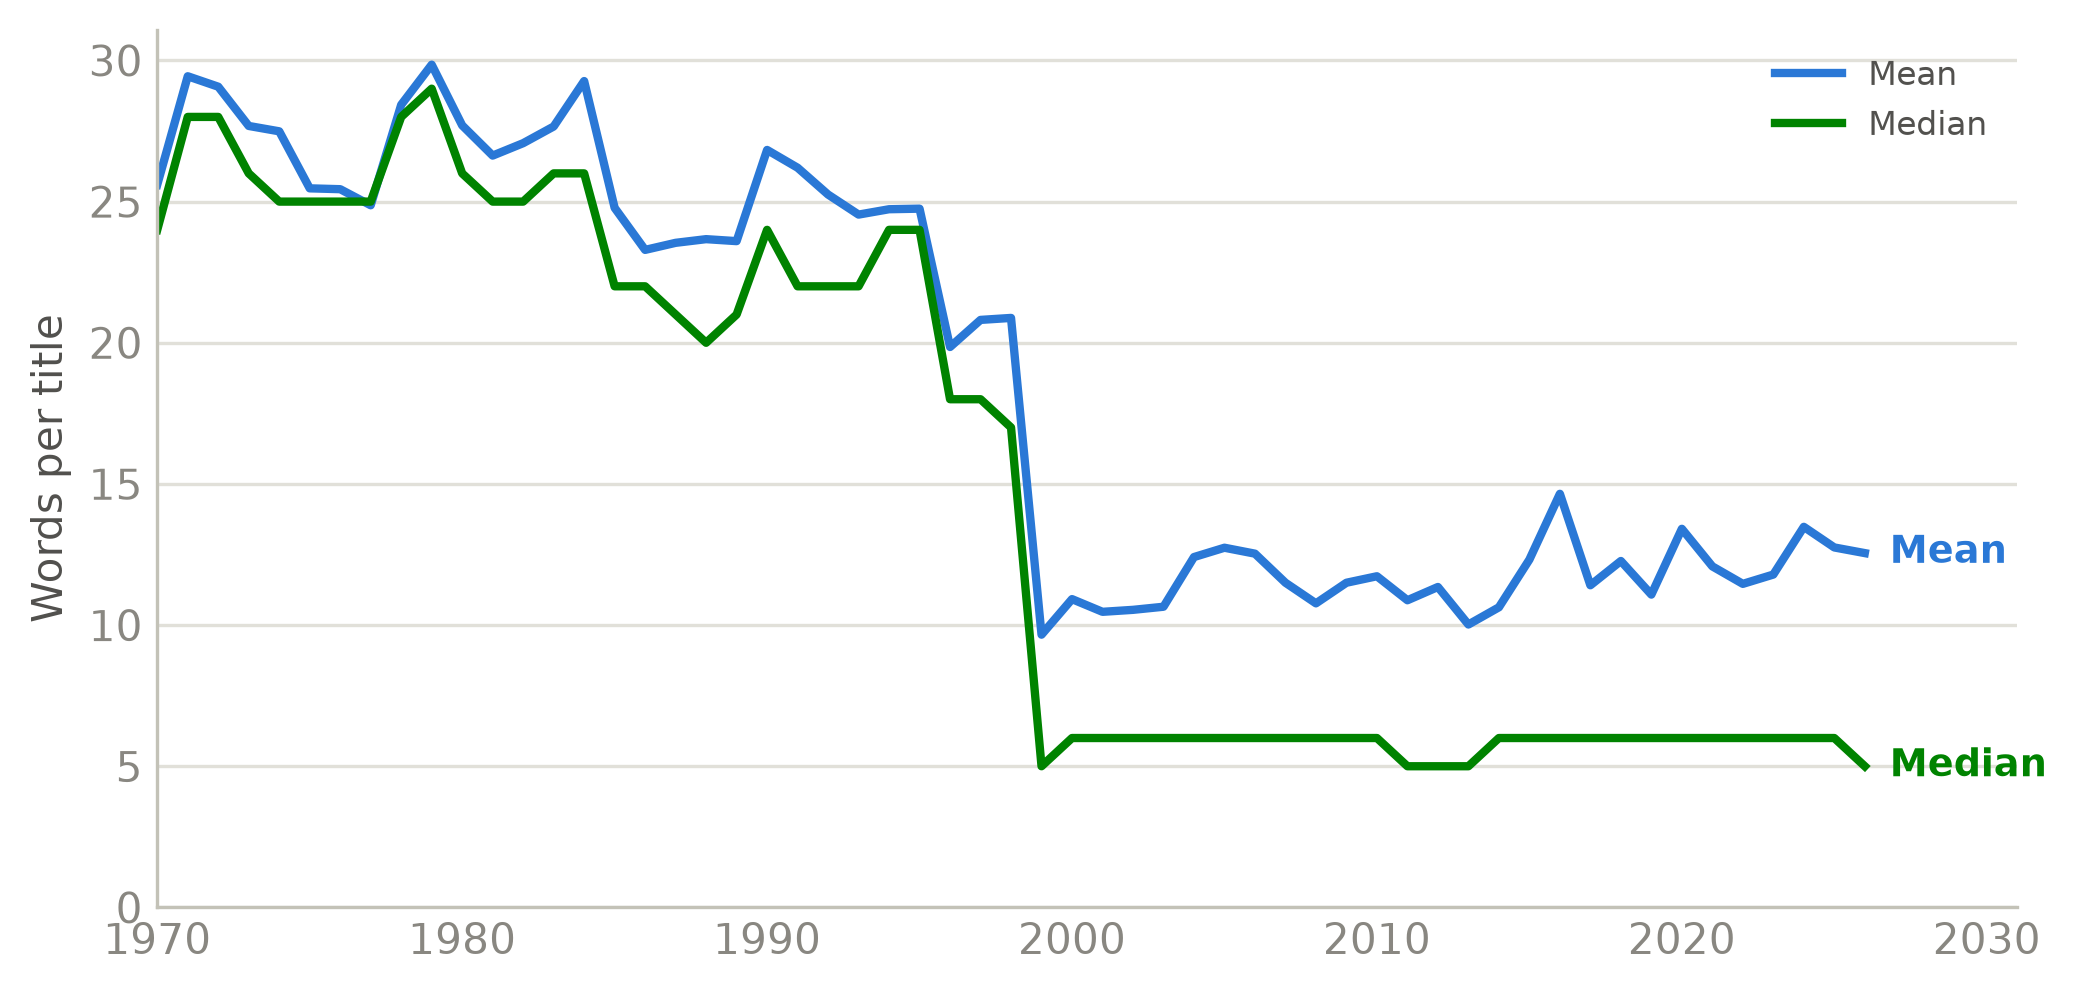

In [4]:
#| label: fig-length
#| fig-cap: "Title length in words: yearly mean and median, 1970–2026."
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(length.year, length.words_mean, color=BLUE, linewidth=2)
ax.plot(length.year, length.words_median, color=GREEN, linewidth=2)
for label, series, color in [
    ("Mean", length.words_mean, BLUE),
    ("Median", length.words_median, GREEN),
]:
    ax.annotate(
        label,
        xy=(length.year.iloc[-1], series.iloc[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="bold",
        va="center",
    )
ax.set_ylabel("Words per title")
ax.set_xlim(1970, 2031)
ax.set_ylim(0, None)
ax.legend(["Mean", "Median"], frameon=False, fontsize=8, loc="upper right")
clean_axis(ax)
plt.show()

## Who fills the gazette's pages

The archive files each note under a top-level heading that mixes branches of
government with fixed sections of the gazette. Its evolution confirms the
reading above ([@fig-sections]): until the late 1980s the gazette was, in
terms of notes, almost exclusively the bulletin of the Executive Branch. The
section for public procurement announcements appears in 1988 and the one for
judicial and general notices in 1996; a decade later the two together already
account for more than half of each year's notes. The Executive, without
reducing its output in absolute terms, ended up surrounded by the paperwork of
public contracting and private-party notices.

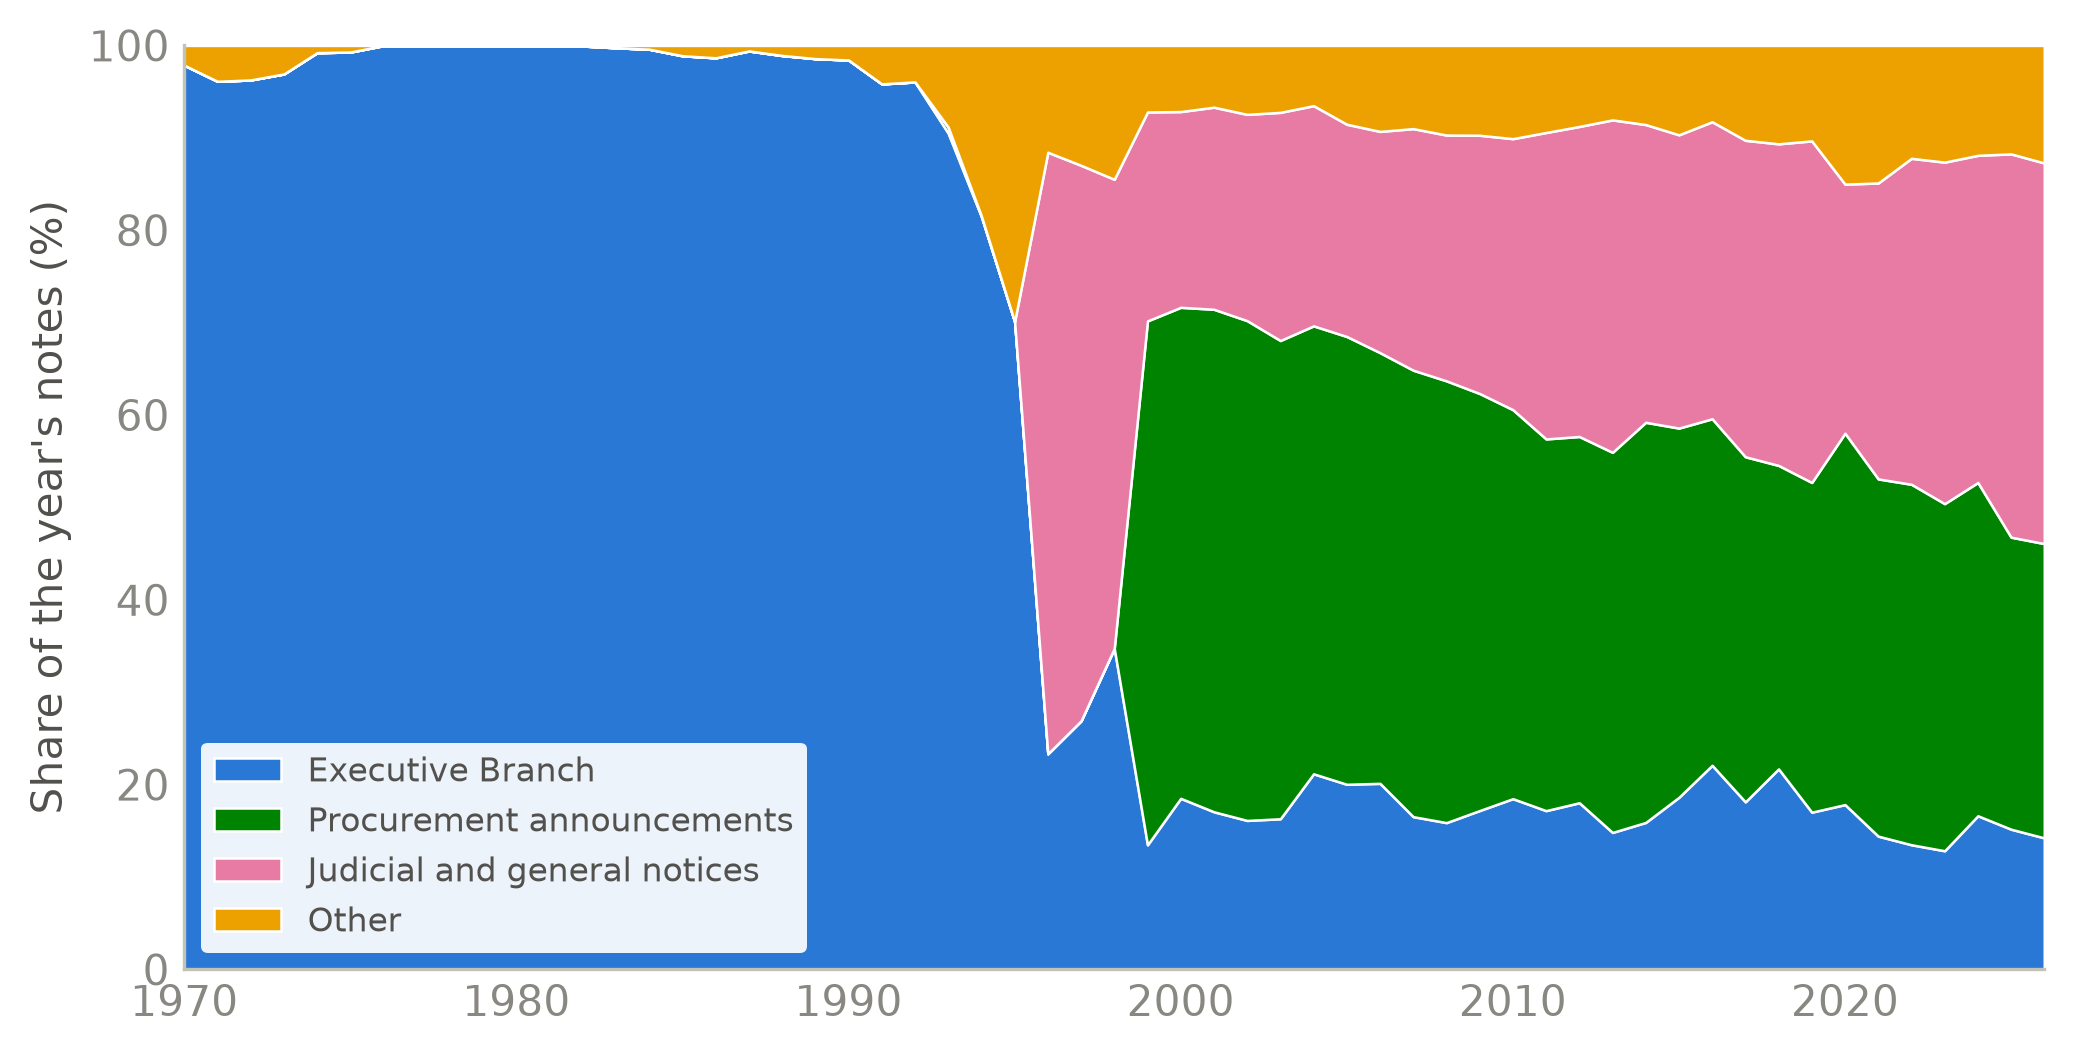

In [5]:
#| label: fig-sections
#| fig-cap: "Yearly composition of the notes by the archive's top-level heading, 1970–2026."
PROCUREMENT = (
    "CONVOCATORIAS PARA CONCURSOS DE ADQUISICIONES, ARRENDAMIENTOS, "
    "OBRAS Y SERVICIOS DEL SECTOR PUBLICO"
)
groups = {
    "PODER EJECUTIVO": "Executive Branch",
    PROCUREMENT: "Procurement announcements",
    "AVISOS JUDICIALES Y GENERALES": "Judicial and general notices",
}
headings["group"] = headings.heading.map(groups).fillna("Other")
comp = headings.pivot_table(index="year", columns="group", values="notes", aggfunc="sum").fillna(0)
order = ["Executive Branch", "Procurement announcements", "Judicial and general notices", "Other"]
comp = comp[order].div(comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.stackplot(
    comp.index,
    [comp[c].values for c in order],
    colors=[BLUE, GREEN, MAGENTA, YELLOW],
    labels=order,
    edgecolor="white",
    linewidth=0.6,
)
ax.set_ylabel("Share of the year's notes (%)")
ax.set_xlim(1970, 2026)
ax.set_ylim(0, 100)
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.92,
    fontsize=8,
    loc="lower left",
)
clean_axis(ax)
plt.show()

## The vocabulary of each era

One last look, now at the full lexicon of the titles. [@tbl-terms] presents
the ten most frequent terms of each decade — Spanish words, since that is the
language of the gazette — after removing function words and the administrative
docket marker "REF" that accompanies the announcements. The 1970s speak the
language of land reform: *municipio* (municipality), *poblado* (village),
*ejido*, *dotación* (land grant), *derechos agrarios* (agrarian rights). That
vocabulary still dominates the 1980s and fades in the 1990s, when generic
institutional terms — *nacional*, *federal*, *estados unidos mexicanos* — take
its place. From the 2000s onward the gazette speaks the language of
administration: *aviso*, *secretaría*, *instituto*, *seguro social*,
*servicios*. In half a century, the DOF went from recording the transformation
of land ownership to documenting the day-to-day operation of the state
apparatus.

In [6]:
#| label: tbl-terms
#| tbl-cap: "The ten most frequent terms in DOF titles by decade (function words and the REF docket marker excluded; the 2020s run through July 2026)."
from IPython.display import Markdown

decades = sorted(terms.decade.unique())
top = {d: terms[terms.decade == d].head(10).term.tolist() for d in decades}
rows = []
for i in range(10):
    rows.append("| " + str(i + 1) + " | " + " | ".join(top[d][i] for d in decades) + " |")
header = "| # | " + " | ".join(f"{d}s" for d in decades) + " |"
separator = "|---" * (len(decades) + 1) + "|"
Markdown("\n".join([header, separator] + rows))

| # | 1970s | 1980s | 1990s | 2000s | 2010s | 2020s |
|---|---|---|---|---|---|---|
| 1 | municipio | municipio | municipio | aviso | aviso | aviso |
| 2 | resolucion | denominado | aviso | estado | secretaria | nacional |
| 3 | denominado | poblado | nacional | federal | estado | secretaria |
| 4 | poblado | resolucion | federal | nacional | nacional | instituto |
| 5 | ejido | ubicado | estados | instituto | instituto | estado |
| 6 | derechos | reg | unidos | secretaria | federal | federal |
| 7 | agrarios | acuerdo | acuerdo | pemex | social | social |
| 8 | privacion | ejido | distrito | comision | municipio | acuerdo |
| 9 | dotacion | derechos | decreto | social | comision | mexicano |
| 10 | numero | agrarios | mexicanos | produccion | acuerdo | servicios |

## What comes next

This exploration deliberately confined itself to the shallowest metadata in
the archive, and even so the titles sufficed to date the digitization of the
gazette, to measure the twilight of the land reform and to document the
bureaucratization of its content. The next installments will go one level
down: toward the automatic classification of the documentary types that the
first word only approximates, and toward the full text of the notes, whose
conversion to Markdown — with the
[nota2md](https://github.com/INGEOTEC/LegalIA/tree/master/packages/nota2md)
and [dof2md](https://github.com/INGEOTEC/LegalIA/tree/master/packages/dof2md)
packages — is under way.

## Methodological note {.unnumbered .appendix}

The data comes from the DOF's open-data JSON service, queried day by day
between January 1, 1970 and July 17, 2026. The aggregates behind the figures
and the table are produced by
[`website/scripts/aggregate_titles.py`](https://github.com/INGEOTEC/LegalIA/blob/master/website/scripts/aggregate_titles.py)
and are versioned alongside this document, so the page can be rebuilt without
the raw archive; when the notebook runs outside the repository (for example on
Google Colab) it fetches them directly from GitHub. For the lexical analysis,
terms were lowercased and stripped of accents, and words shorter than three
characters, Spanish function words and the "REF" docket marker were discarded.